# SROIE OCR Baseline

This notebook runs the Tesseract OCR baseline on a few validated canonical SROIE receipts. It is intended for qualitative inspection only: it does not extract receipt fields or train a model.

Tesseract must be installed separately from the Python package. If it is not installed or is not on `PATH`, the notebook records and displays failure statuses instead of fabricating OCR output.

In [5]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.sroie import load_sroie_dataset
from src.ocr import run_batch_ocr

DATASET_ROOT = PROJECT_ROOT / "data" / "raw"
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"
PREVIEW_OUTPUT = PROCESSED_ROOT / "sroie_ocr_preview.jsonl"

dataset = load_sroie_dataset(DATASET_ROOT, strict=False)
preview_records = dataset.head(3).to_dict("records")
print(f"Validated canonical samples available: {len(dataset)}")
print(f"Receipts selected for OCR preview: {len(preview_records)}")

Validated canonical samples available: 624
Receipts selected for OCR preview: 3


In [6]:
summary = run_batch_ocr(preview_records, PREVIEW_OUTPUT)
results = [
    json.loads(line)
    for line in PREVIEW_OUTPUT.read_text(encoding="utf-8").splitlines()
]

print(f"OCR results written to: {PREVIEW_OUTPUT.relative_to(PROJECT_ROOT)}")
print(
    f"Statuses: success={summary.success}, empty={summary.empty}, "
    f"failure={summary.failure}"
)

for result in results:
    print(f"\n[{result['image_id']}] status={result['status']}")
    if result["status"] == "success":
        print(result["text"] or "No recognized text")
    else:
        print(f"{result['error_type']}: {result['error_message']}")

OCR results written to: data\processed\sroie_ocr_preview.jsonl
Statuses: success=3, empty=0, failure=0

[X00016469612] status=success
tan woon yann
BOOK TA -K (TAMAN DAYA) SDN BHD
PRON 7-W
NO.5? $5,57 & 59, JALAN SAGU 18,
TAMAN DAYA
81100 JOHOR BAHRU,
JOHOR.
WAM MITA At
Document Ho : TDO1167104
Date 25/12/2018 8:13:39 PM
Cashier MANIS.
Member
CASH BILL
CODE/DESC PRICE Dise AMOUIHT
Quy RM RM
0556929040118 AF MODELLING CLAY KIDDY FISH
1PC + 9.00) 0,00 9.00
Total : 9,00
Rour ding Adjustment 0.00
Round. :d Total (RM): 9.00
Cash oy 40.00.
CHANGE 00
GOODS SOLD ARE NOT RETURNAP
EXCHANGEABLE
THANK YOU
PLEASE COME AGAIN t

[X00016469619] status=success
tan woon yann
INDAH GIFT & HOME BECO
27, JALAN DEDAP 13,
TANAN JOHOR JAYA,
81100 JOHOR BAHRU, JOHOR.
Tel:07-3507405 Fax:07-35598160
RECEIPT
19/10/2018 20:49:59 #01
Cashier: CN Location/SP: 05 /0531
MB: 4026588
Room No: Of 050100025279
Desc/Iten Qty Price Ant/RH)
ST-PRIVILEGE CARD/GD INDAH
88888 1 10.00 10.00
GF-TABLE LAMP/STITCH <i>
62483 1 55.90

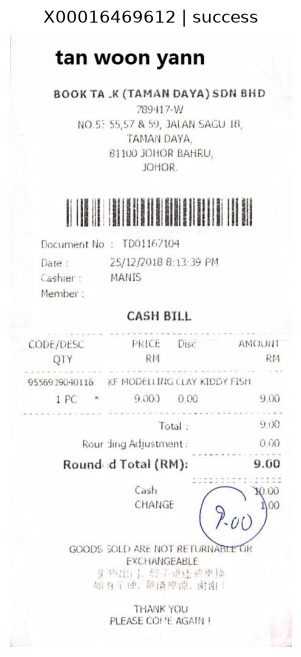

,text,bbox,confidence
0,tan,"[75, 32, 51, 23]",92.0
1,woon,"[138, 37, 91, 18]",92.0
2,yann,"[241, 37, 78, 26]",92.0
3,BOOK,"[73, 97, 52, 13]",96.0
4,TA,"[132, 97, 23, 13]",89.0
...,...,...,...
83,YOU,"[261, 945, 31, 12]",95.0
84,PLEASE,"[165, 963, 53, 13]",96.0
85,COME,"[225, 963, 39, 13]",88.0
86,AGAIN,"[273, 964, 45, 12]",22.0


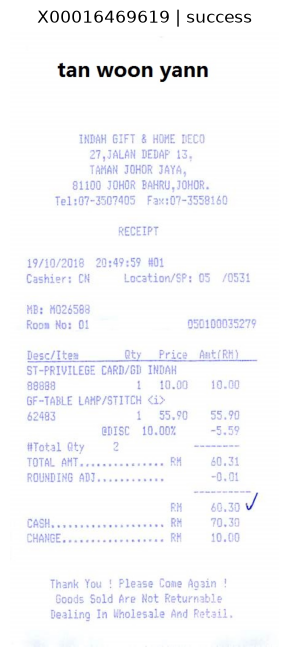

,text,bbox,confidence
0,tan,"[77, 52, 53, 23]",93.0
1,woon,"[141, 57, 91, 18]",90.0
2,yann,"[244, 57, 78, 26]",91.0
3,INDAH,"[113, 168, 43, 16]",83.0
4,GIFT,"[168, 168, 35, 15]",91.0
...,...,...,...
78,Retur,"[253, 917, 40, 15]",89.0
79,Healing,"[67, 943, 63, 19]",52.0
80,In,"[142, 943, 16, 14]",95.0
81,Wholesale,"[169, 942, 83, 15]",95.0


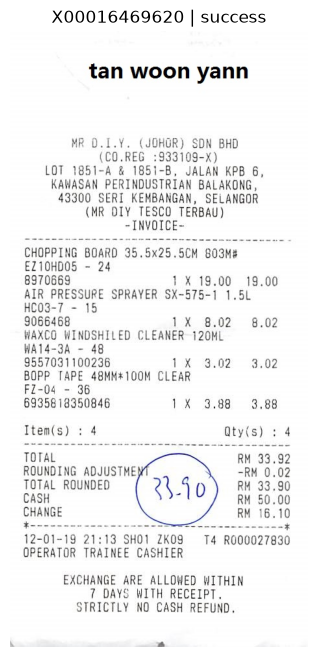

,text,bbox,confidence
0,tan,"[122, 50, 51, 23]",92.0
1,woon,"[185, 55, 91, 18]",92.0
2,yann,"[288, 55, 78, 26]",92.0
3,MR,"[96, 165, 17, 14]",61.0
4,O.1.¥.,"[127, 165, 57, 15]",61.0
...,...,...,...
115,RECEIPT.,"[247, 859, 78, 16]",86.0
116,STRICTLY,"[103, 880, 79, 15]",96.0
117,NO,"[196, 880, 18, 15]",96.0
118,CASH,"[227, 880, 38, 16]",95.0


In [7]:
for result in results:
    figure, axis = plt.subplots(figsize=(10, 8))
    try:
        image = Image.open(result["image_path"])
        axis.imshow(image)
    except (OSError, ValueError) as error:
        axis.text(0.5, 0.5, f"Image unavailable: {error}", ha="center", va="center")
    axis.set_title(f"{result['image_id']} | {result['status']}")
    axis.axis("off")
    plt.show()

    words = pd.DataFrame(result["words"])
    if words.empty:
        print("No word-level OCR data available.")
    else:
        display(words)

## Full SROIE OCR Run

Run Tesseract over all validated SROIE samples and save the OCR results for error analysis.

In [8]:
from src.ocr import run_sroie_ocr

summary = run_sroie_ocr(
    dataset_root=PROJECT_ROOT / "data" / "raw",
    output_path=PROJECT_ROOT / "data" / "processed" / "sroie_ocr.jsonl",
    strict=False,
)

print(f"OCR results written to: {summary.output_path}")
print(f"Total:   {summary.total}")
print(f"Success: {summary.success}")
print(f"Empty:   {summary.empty}")
print(f"Failure: {summary.failure}")

OCR empty for X51006388069: Tesseract returned no text
OCR empty for X51006392273: Tesseract returned no text
OCR empty for X51006619862: Tesseract returned no text
OCR empty for X51006620187: Tesseract returned no text
OCR empty for X51006733494: Tesseract returned no text
OCR empty for X51006828217: Tesseract returned no text
OCR empty for X51007339639: Tesseract returned no text
OCR empty for X51008142034: Tesseract returned no text


OCR results written to: c:\Users\chech\Documents\AI-Document-Intelligence\data\processed\sroie_ocr.jsonl
Total:   624
Success: 616
Empty:   8
Failure: 0
